# Peeking Inside CLIP's Intermediate Blocks  ·  RINE explorer

**Goal of this notebook** — understand *why* the RINE paper (Koutlis & Papadopoulos, ECCV 2024) harvests
features from **intermediate encoder blocks** instead of only the final layer.

We will:
1. Load the exact backbone RINE uses — a **frozen CLIP ViT-L/14**.
2. Print the model's structure so you can see what's actually inside.
3. Attach *hooks* to **every** transformer block so we can read what each one outputs.
4. Start at the **last block** and **"unblock" earlier blocks one step at a time**, visualizing
   what each captures.

> **The thesis you should see for yourself:** the *final* block encodes high-level *semantics*
> ("this is a dog"). The *intermediate / shallow* blocks still hold low-level **edges, textures and
> frequency artifacts** — and those are where synthetic-image fingerprints live.

**Runtime:** set `Runtime → Change runtime type → GPU` (T4 is plenty).


## 1 · Install dependencies

`open_clip_torch` gives us the same OpenAI CLIP weights RINE builds on.


In [1]:
# Run once per Colab session
!pip -q install open_clip_torch ftfy regex
print("done")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.6 MB/s eta 0:00:00
done


## 2 · Imports & device check

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import open_clip
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch:", torch.__version__)
print("Device:", device)
if device == "cpu":
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> GPU")


Torch: 2.11.0+cu128
Device: cuda


## 3 · Load the frozen CLIP ViT-L/14 backbone

This is exactly what RINE freezes and reads features from. `ViT-L-14` has a **24-block**
transformer with width 1024 — so there are 24 intermediate representations to explore.


In [3]:
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-L-14", pretrained="openai"
)
model = model.to(device).eval()

# RINE keeps CLIP fully frozen -- we only ever *read* from it.
for p in model.parameters():
    p.requires_grad_(False)

print("Model loaded and frozen.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Model loaded and frozen.


## 4 · Look inside — the model's structure

Before visualizing anything, let's literally see what the network is made of.
The vision tower lives at `model.visual`; its transformer blocks are a `ModuleList` at
`model.visual.transformer.resblocks`.


In [4]:
visual = model.visual
blocks = visual.transformer.resblocks   # the list of intermediate encoder blocks
NUM_BLOCKS = len(blocks)

print(f"Number of transformer blocks : {NUM_BLOCKS}")
print(f"Embedding width (token dim)   : {visual.transformer.width}")
print(f"Patch size                    : {visual.patch_size if hasattr(visual,'patch_size') else '14 (ViT-L/14)'}")

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"\nTotal vision-tower params     : {count_params(visual)/1e6:.1f} M")
print(f"Params in ONE block           : {count_params(blocks[0])/1e6:.2f} M")


Number of transformer blocks : 24
Embedding width (token dim)   : 1024
Patch size                    : (14, 14)

Total vision-tower params     : 304.0 M
Params in ONE block           : 12.60 M


In [5]:
# What does a single block contain? (attention + MLP + norms = a standard Transformer block)
print(blocks[0])


ResidualAttentionBlock(
  (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
  )
  (ls_1): Identity()
  (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
    (gelu): GELU(approximate='none')
    (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
  )
  (ls_2): Identity()
)


In [6]:
# High-level map of the whole vision tower (top-level children only, to keep it readable)
for name, child in visual.named_children():
    print(f"{name:20s} -> {child.__class__.__name__}")


conv1                -> Conv2d
patch_dropout        -> Identity
ln_pre               -> LayerNorm
transformer          -> Transformer
ln_post              -> LayerNorm


### How an image becomes tokens

CLIP ViT-L/14 at 224x224 cuts the image into 14x14 patches → a **16 x 16 = 256 patch grid**,
then prepends a **CLS token** → **257 tokens**, each a 1024-dim vector.

- **CLS token** (index 0): a global summary → this is what RINE collects from every block.
- **256 patch tokens**: keep *spatial* position → we reshape them back to a 16x16 grid to *see*
  what a block is responding to.


## 5 · Load an image to probe

Drop in any URL, or set `USE_UPLOAD = True` to upload your own (try an AI-generated image!).


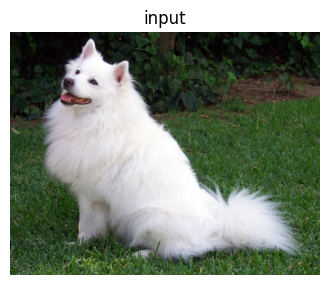

Preprocessed tensor: (1, 3, 224, 224)


In [7]:
USE_UPLOAD = False
IMG_URL = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

if USE_UPLOAD:
    from google.colab import files
    up = files.upload()
    fname = next(iter(up))
    pil_img = Image.open(fname).convert("RGB")
else:
    r = requests.get(IMG_URL, timeout=30)
    pil_img = Image.open(BytesIO(r.content)).convert("RGB")

plt.figure(figsize=(4,4)); plt.imshow(pil_img); plt.axis("off"); plt.title("input"); plt.show()

img = preprocess(pil_img).unsqueeze(0).to(device)
print("Preprocessed tensor:", tuple(img.shape))   # (1, 3, 224, 224)


## 6 · Attach hooks to every block

A *forward hook* lets us capture a block's output **without modifying the model**. We register one
on all 24 blocks, run the image through once, and keep every intermediate representation.


In [8]:
captured = {}   # block_index -> output tensor

def make_hook(idx):
    def hook(module, inp, out):
        captured[idx] = out.detach()
    return hook

handles = [blk.register_forward_hook(make_hook(i)) for i, blk in enumerate(blocks)]

with torch.no_grad():
    _ = model.encode_image(img)

for h in handles:   # always remove hooks when done
    h.remove()

print(f"Captured outputs from {len(captured)} blocks.")


Captured outputs from 24 blocks.


In [9]:
# open_clip may give tokens as (seq, batch, dim) or (batch, seq, dim).
# This helper normalizes either into: cls vector + a (16,16,dim) spatial grid.
SEQ = None

def split_tokens(out):
    t = out
    if t.dim() == 3:
        # find the 257-token axis
        if t.shape[0] == 1:            # (batch, seq, dim)
            t = t[0]                   # -> (seq, dim)
        elif t.shape[1] == 1:          # (seq, batch, dim)
            t = t[:, 0, :]             # -> (seq, dim)
        else:
            t = t[0]
    cls = t[0]                         # (dim,)
    patches = t[1:]                    # (256, dim)
    n = patches.shape[0]
    side = int(round(n ** 0.5))
    grid = patches.reshape(side, side, -1)   # (16,16,dim)
    return cls, grid

cls0, grid0 = split_tokens(captured[NUM_BLOCKS-1])
print("CLS vector :", tuple(cls0.shape))
print("Patch grid :", tuple(grid0.shape))


CLS vector : (1024,)
Patch grid : (16, 16, 1024)


## 7 · Turn a block's tokens into a picture (PCA)

Each patch is a 1024-dim vector — we can't see 1024 channels. So we run **PCA** over the 256 patch
vectors and keep the top 3 components → map them to RGB. The result shows the *spatial structure a
block responds to*: blobs/objects in late blocks, fine edges & texture in early ones.


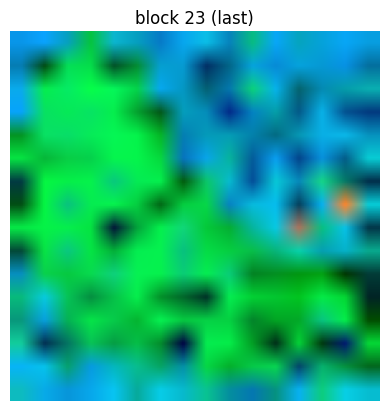

In [10]:
def pca_rgb(grid):
    """(side,side,dim) -> (side,side,3) normalized to [0,1] via top-3 PCA."""
    side = grid.shape[0]
    x = grid.reshape(-1, grid.shape[-1]).float()
    x = x - x.mean(0, keepdim=True)
    # top-3 right singular vectors = principal components
    U, S, V = torch.linalg.svd(x, full_matrices=False)
    comps = x @ V[:3].T                      # (256, 3)
    comps = comps.reshape(side, side, 3)
    mn = comps.amin(dim=(0,1), keepdim=True)
    mx = comps.amax(dim=(0,1), keepdim=True)
    return ((comps - mn) / (mx - mn + 1e-6)).cpu().numpy()

def upscaled(grid):
    """PCA image, bilinearly upscaled to 224 for nicer viewing."""
    rgb = pca_rgb(grid)                       # (16,16,3)
    t = torch.tensor(rgb).permute(2,0,1).unsqueeze(0)
    t = F.interpolate(t, size=224, mode="bilinear", align_corners=False)
    return t[0].permute(1,2,0).numpy()

# quick sanity check on the last block
plt.imshow(upscaled(grid0)); plt.axis("off"); plt.title(f"block {NUM_BLOCKS-1} (last)"); plt.show()


## 8 · The main event — "unblock" stepwise, last → first

We reveal blocks **one step at a time, starting from the last**. Watch the representation change as
we move *backwards* (deeper into the encoder): late blocks look like clean object-level segments;
as you step earlier, the maps break up into **finer edges and texture** — the low-level signal RINE
argues is essential for catching fakes.


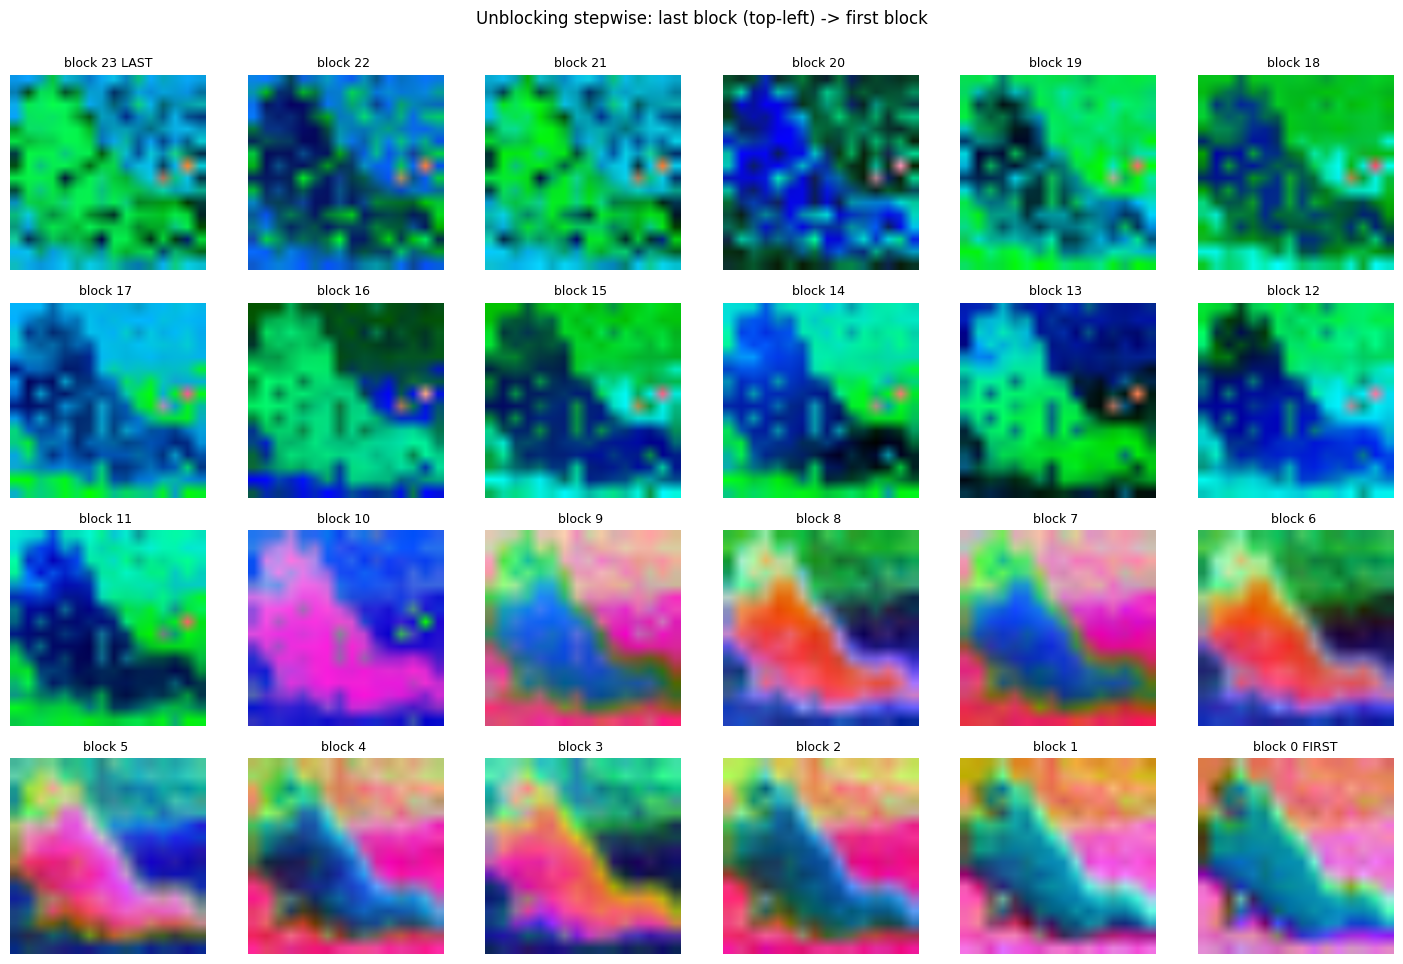

In [11]:
# Step from the LAST block back to the FIRST.
step_order = list(range(NUM_BLOCKS-1, -1, -1))   # 23, 22, ..., 1, 0

cols = 6
rows = int(np.ceil(len(step_order)/cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.4, rows*2.4))
axes = axes.flatten()

for ax, idx in zip(axes, step_order):
    _, grid = split_tokens(captured[idx])
    ax.imshow(upscaled(grid))
    tag = "LAST" if idx == NUM_BLOCKS-1 else ("FIRST" if idx == 0 else "")
    ax.set_title(f"block {idx} {tag}", fontsize=9)
    ax.axis("off")

for ax in axes[len(step_order):]:
    ax.axis("off")

plt.suptitle("Unblocking stepwise: last block (top-left) -> first block", y=1.0)
plt.tight_layout(); plt.show()


### Interactive single-step version

Prefer to reveal them *one at a time*? Change `step` and re-run — `step=0` shows only the last block,
`step=1` adds the second-to-last, and so on, so you "unblock" deeper layers progressively.


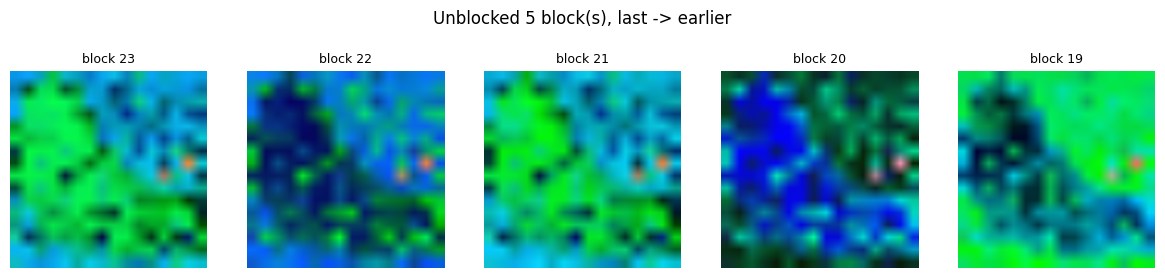

In [12]:
step = 4   # 0 = last block only; increase to walk earlier, one block per step

revealed = step_order[:step+1]
n = len(revealed)
fig, axes = plt.subplots(1, n, figsize=(n*2.4, 2.6))
if n == 1:
    axes = [axes]
for ax, idx in zip(axes, revealed):
    _, grid = split_tokens(captured[idx])
    ax.imshow(upscaled(grid)); ax.axis("off")
    ax.set_title(f"block {idx}", fontsize=9)
plt.suptitle(f"Unblocked {n} block(s), last -> earlier", y=1.05)
plt.tight_layout(); plt.show()


## 9 · Why intermediate blocks matter (the RINE intuition)

RINE doesn't visualize patches — it collects the **CLS token from every block** and lets a tiny
trainable module learn *how much each block matters*. Two quick diagnostics below show why no single
block is enough:

- **CLS drift:** how different each block's CLS token is from the final one (cosine distance). If
  early blocks were redundant, this would be ~0 everywhere — it isn't.
- **Per-block "energy":** the variance of patch features — a rough proxy for how much structured
  signal a block carries.


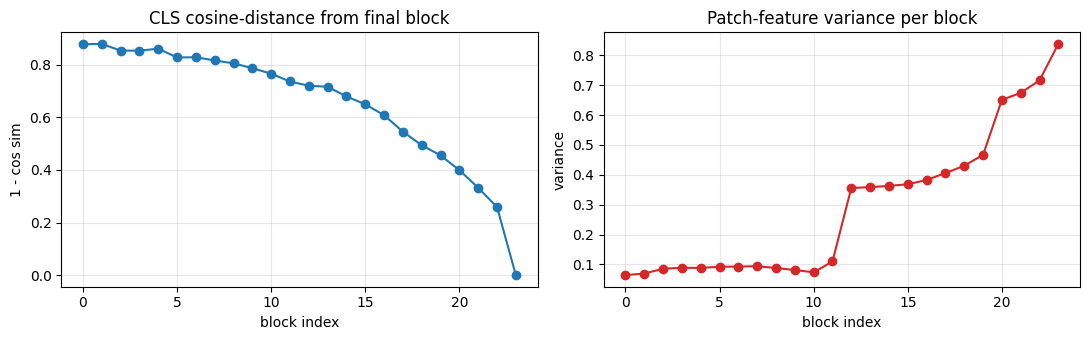

Takeaway: intermediate blocks carry distinct, non-redundant information -> RINE fuses ALL of them instead of using only the last.


In [13]:
last_cls, _ = split_tokens(captured[NUM_BLOCKS-1])
last_cls = last_cls.float()

drift, energy = [], []
for i in range(NUM_BLOCKS):
    cls, grid = split_tokens(captured[i])
    cls = cls.float()
    cos = F.cosine_similarity(cls.unsqueeze(0), last_cls.unsqueeze(0)).item()
    drift.append(1 - cos)
    energy.append(grid.float().var().item())

fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
ax[0].plot(range(NUM_BLOCKS), drift, marker="o")
ax[0].set_title("CLS cosine-distance from final block")
ax[0].set_xlabel("block index"); ax[0].set_ylabel("1 - cos sim"); ax[0].grid(alpha=.3)

ax[1].plot(range(NUM_BLOCKS), energy, marker="o", color="tab:red")
ax[1].set_title("Patch-feature variance per block")
ax[1].set_xlabel("block index"); ax[1].set_ylabel("variance"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Takeaway: intermediate blocks carry distinct, non-redundant information -> "
      "RINE fuses ALL of them instead of using only the last.")


## 10 · Mini RINE-style feature stack

Finally, the operation at the heart of RINE: stack the CLS token from **every** block into one
feature tensor. RINE feeds exactly this (per image) into its small projection + importance-estimator
+ classifier head — the only trainable parts.


In [14]:
cls_stack = torch.stack([split_tokens(captured[i])[0] for i in range(NUM_BLOCKS)], dim=0)
print("RINE-style feature stack:", tuple(cls_stack.shape), "  (blocks, dim)")
print("This (24 x 1024) per-image tensor is what RINE's trainable head learns to weight & classify.")


RINE-style feature stack: (24, 1024)   (blocks, dim)
This (24 x 1024) per-image tensor is what RINE's trainable head learns to weight & classify.


## What to try next

- Set `USE_UPLOAD = True` and feed a **real photo vs an AI-generated image** — compare the early-block
  texture maps; generator fingerprints often show up there.
- Swap the backbone to `ViT-B-16` (`open_clip.create_model_and_transforms("ViT-B-16", ...)`) and note
  the different block count / patch grid.
- Plot **attention maps** instead of PCA (hook the attention weights inside `blocks[i].attn`).
- Re-read `notes/RINE_paper_notes.md` §"The key insight" alongside the section-8 figure — that grid
  *is* the paper's motivation, made visible.
